In [ ]:
# 1. Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

df = pd.read_csv("/content/DOB Violations.csv", low_memory=False)

In [ ]:
df.head(10)

,ISN_DOB_BIS_EXTRACT,ECB_VIOLATION_NUMBER,ECB_VIOLATION_STATUS,DOB_VIOLATION_NUMBER,BIN,BORO,BLOCK,LOT,HEARING_DATE,HEARING_TIME,...,SECTION_LAW_DESCRIPTION7,INFRACTION_CODE8,SECTION_LAW_DESCRIPTION8,INFRACTION_CODE9,SECTION_LAW_DESCRIPTION9,INFRACTION_CODE10,SECTION_LAW_DESCRIPTION10,AGGRAVATED_LEVEL,HEARING_STATUS,CERTIFICATION_STATUS
0,868675,35483536P,RESOLVE,01012024HPD413,4229229.0,4,10701.0,36.0,20240806,1030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,DISMISSED,N/A - DISMISSED
1,1701371,39102525N,RESOLVE,NaN,4010768.0,4,662.0,41.0,20240312,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AGGRAVATED OFFENSE LEVEL 1,IN VIOLATION,CERTIFICATE ACCEPTED
2,1308716,39102524L,RESOLVE,NaN,2051400.0,2,4435.0,47.0,20240709,900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,IN VIOLATION,CERTIFICATE ACCEPTED
3,1697903,39102551R,RESOLVE,NaN,3012122.0,3,760.0,36.0,20240313,1030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,DISMISSED,N/A - DISMISSED
4,1618967,39102588K,ACTIVE,NaN,2014617.0,2,3212.0,88.0,20240315,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,DEFAULT,NO COMPLIANCE RECORDED
5,1713417,39102582J,RESOLVE,NaN,4433860.0,4,3175.0,1.0,20240725,1030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,DISMISSED,N/A - DISMISSED
6,1618948,39102548X,RESOLVE,NaN,2056485.0,2,4608.0,17.0,20240315,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,DEFAULT,COMPLIANCE-INSP/DOC
7,1694079,39524442H,RESOLVE,NaN,1036892.0,1,1311.0,13.0,20240307,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,IN VIOLATION,CERTIFICATE ACCEPTED
8,517792,39524429N,RESOLVE,NaN,4213952.0,4,9993.0,1.0,20240312,830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,IN VIOLATION,CERTIFICATE ACCEPTED
9,1531410,39102549H,ACTIVE,NaN,3050644.0,3,1803.0,74.0,20240313,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,IN VIOLATION,NO COMPLIANCE RECORDED


In [ ]:
# 3. Data Cleaning

# Standardize column names
df.columns = df.columns.str.strip()

# Drop rows where BORO is missing
df = df.dropna(subset=['BORO'])



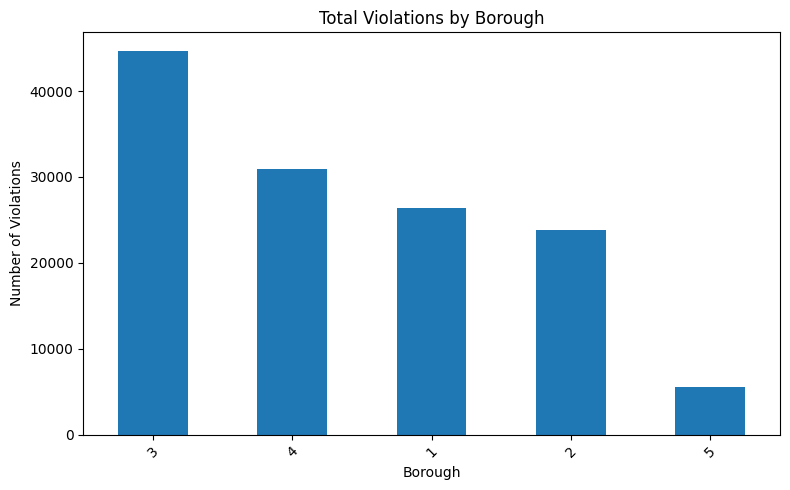

In [ ]:
# GRAPH 1: Violations by Borough-Shows which borough has the most violations

boro_counts = df['BORO'].value_counts()

plt.figure(figsize=(8,5))
boro_counts.plot(kind='bar')

plt.title("Total Violations by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Violations")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131213 entries, 0 to 131212
Data columns (total 46 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ISN_DOB_BIS_EXTRACT        131213 non-null  int64  
 1   ECB_VIOLATION_NUMBER       131213 non-null  object 
 2   ECB_VIOLATION_STATUS       131213 non-null  object 
 3   DOB_VIOLATION_NUMBER       32573 non-null   object 
 4   BIN                        131055 non-null  float64
 5   BORO                       131213 non-null  int64  
 6   BLOCK                      130401 non-null  float64
 7   LOT                        130401 non-null  float64
 8   HEARING_DATE               131213 non-null  int64  
 9   HEARING_TIME               131213 non-null  int64  
 10  SERVED_DATE                131213 non-null  int64  
 11  ISSUE_DATE                 131213 non-null  int64  
 12  SEVERITY                   131213 non-null  object 
 13  VIOLATION_TYPE             13

In [ ]:
# Convert penalty column to numeric

df['PENALITY_IMPOSED'] = pd.to_numeric(df['PENALITY_IMPOSED'], errors='coerce')

# Drop missing values
df = df.dropna(subset=['BORO', 'PENALITY_IMPOSED'])

In [ ]:
# Group Data

penalty_by_boro = df.groupby('BORO')['PENALITY_IMPOSED'].sum().sort_values(ascending=False)


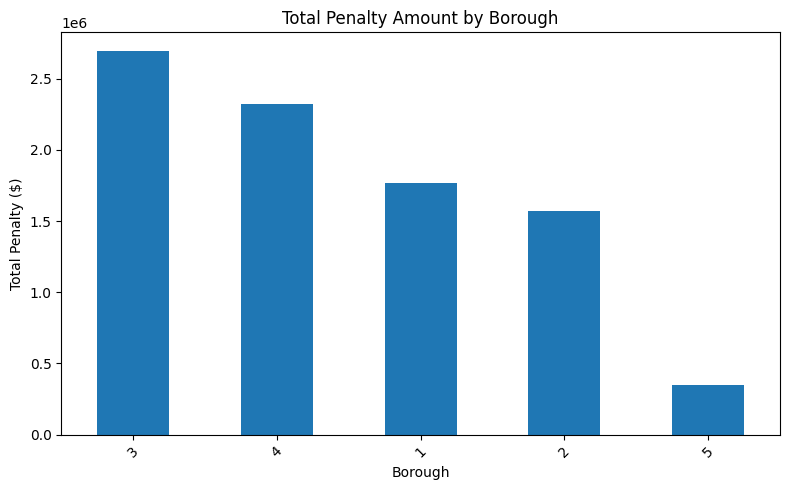

In [ ]:
# Plot Graph

plt.figure(figsize=(8,5))
penalty_by_boro.plot(kind='bar')

plt.title("Total Penalty Amount by Borough")
plt.xlabel("Borough")
plt.ylabel("Total Penalty ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

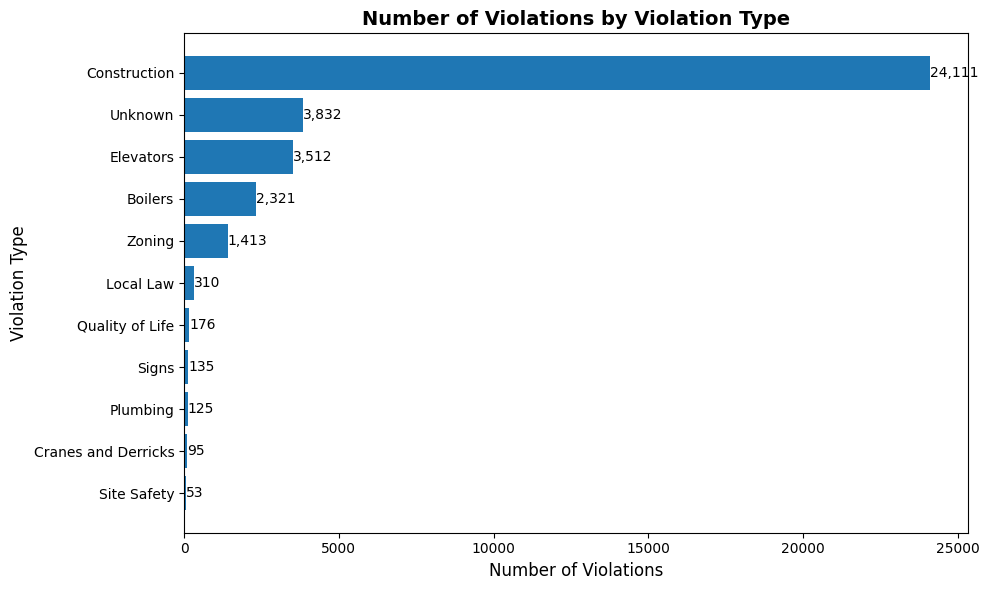

In [ ]:


# Group Data

violation_counts = (
    df['VIOLATION_TYPE']
    .value_counts()
    .sort_values(ascending=True)   # for horizontal chart
)


# Plot Graph

plt.figure(figsize=(10,6))

bars = plt.barh(violation_counts.index, violation_counts.values)

plt.title("Number of Violations by Violation Type", fontsize=14, weight='bold')
plt.xlabel("Number of Violations", fontsize=12)
plt.ylabel("Violation Type", fontsize=12)

# Add labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width,
             bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',
             va='center',
             fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
#It shows which types of violations occur most frequently and in which borough is helping identify the most common compliance issues.